In [1]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [2]:
# 1. 고위험군 CAMEO 코드 리스트
target_cameo_codes = [ 
    '150', '151', '152', '153', '154', '155', 
    '190', '191', '192', '193', '194', '195', '196', 
    '200', '201', '202', '203', '204'
]
formatted_codes = ", ".join([f"'{code}'" for code in target_cameo_codes])

query = f"""
SELECT 
    SQLDATE, 
    IsRootEvent,
    EventCode, 
    GoldsteinScale, 
    NumMentions,
    AvgTone,
    ActionGeo_Type,
    ActionGeo_Lat, 
    ActionGeo_Long, 
    SOURCEURL
FROM `gdelt-bq.full.events`
WHERE SQLDATE >= 20130401
  AND IsRootEvent = 1
  AND ActionGeo_Type IN (3, 4, 5)
  AND (
    (Actor1CountryCode = 'CHN' AND Actor2CountryCode = 'TWN') OR 
    (Actor1CountryCode = 'TWN' AND Actor2CountryCode = 'CHN')
  )
  AND EventCode IN ({formatted_codes})
"""

project_id = "project-fe69a478-943f-4a4a-bc6" # 로그인창 연결됨
df = pandas_gbq.read_gbq(query, project_id=project_id)

# 결과 확인
print(f"2013년부터 2026년 현재까지 총 {len(df)}건의 데이터를 불러왔습니다.(필터링 적용 O)")
display(df.head())

Downloading: 100%|██████████|
2013년부터 2026년 현재까지 총 11896건의 데이터를 불러왔습니다.(필터링 적용 O)


,SQLDATE,IsRootEvent,EventCode,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long,SOURCEURL
0,20160820,1,192,-9.5,5,-3.697749,4,27.9383,116.293,http://www.chinapost.com.tw/taiwan/national/na...
1,20160820,1,192,-9.5,5,-3.697749,4,27.9383,116.293,http://www.chinapost.com.tw/taiwan/national/na...
2,20160820,1,194,-10.0,8,-1.573850,4,39.9289,116.388,http://www.newsnow.in/news/taiwan-president-sa...
3,20160820,1,194,-10.0,2,-1.573850,4,25.0478,121.532,http://www.newsnow.in/news/taiwan-president-sa...
4,20160911,1,190,-10.0,8,-14.525140,4,25.0478,121.532,http://www.wcyb.com/news/taiwan-tour-bus-drive...


In [4]:
df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], format='%Y%m%d')

print(df.shape)

(11896, 10)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11896 entries, 0 to 11895
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   SQLDATE         11896 non-null  datetime64[ns]
 1   IsRootEvent     11896 non-null  Int64         
 2   EventCode       11896 non-null  object        
 3   GoldsteinScale  11896 non-null  float64       
 4   NumMentions     11896 non-null  Int64         
 5   AvgTone         11896 non-null  float64       
 6   ActionGeo_Type  11896 non-null  Int64         
 7   ActionGeo_Lat   11896 non-null  float64       
 8   ActionGeo_Long  11896 non-null  float64       
 9   SOURCEURL       11896 non-null  object        
dtypes: Int64(3), datetime64[ns](1), float64(4), object(2)
memory usage: 964.4+ KB


In [7]:
df.isna().sum() # 결측치 없음.

SQLDATE           0
IsRootEvent       0
EventCode         0
GoldsteinScale    0
NumMentions       0
AvgTone           0
ActionGeo_Type    0
ActionGeo_Lat     0
ActionGeo_Long    0
SOURCEURL         0
dtype: int64

In [6]:
df.describe()

,SQLDATE,IsRootEvent,GoldsteinScale,NumMentions,AvgTone,ActionGeo_Type,ActionGeo_Lat,ActionGeo_Long
count,11896,11896.0,11896.000000,11896.0,11896.000000,11896.0,11896.000000,11896.000000
mean,2021-07-11 15:27:50.477471488,1.0,-8.818132,13.301278,-2.505654,3.993863,30.852916,109.915948
min,2013-04-01 00:00:00,1.0,-10.000000,1.0,-18.181818,3.0,-41.300000,-157.972000
25%,2019-09-04 18:00:00,1.0,-10.000000,2.0,-3.900616,4.0,24.653225,116.388000
50%,2022-06-11 00:00:00,1.0,-10.000000,5.0,-2.523966,4.0,25.047800,118.318000
75%,2023-08-03 00:00:00,1.0,-7.200000,10.0,-1.150748,4.0,39.928900,121.532000
max,2026-04-30 00:00:00,1.0,-7.200000,1468.0,10.550459,5.0,67.939700,178.417000
std,NaN,0.0,1.343997,51.404355,2.355877,0.248163,9.124972,39.480155


## 1. 기사량(NumMentions) 기반 EDA

- 증가율 분포
- 기간별 기사량 분포 -> 최소 기사량? 선정?

In [8]:
## 날짜 기준 총 기사량으로 저장..
daily_counts = (
    df.groupby('SQLDATE')['NumMentions']
    .sum()
    .reset_index()
    .sort_values('SQLDATE')
)

daily_counts.head()

,SQLDATE,NumMentions
0,2013-04-01,8
1,2013-04-14,2
2,2013-04-15,2
3,2013-04-22,2
4,2013-09-06,26


In [9]:
## 7 / 14 / 30 기준 이동평균선 생성
for window in [7, 14, 30]:
    daily_counts[f'ma_{window}'] = (
        daily_counts['NumMentions']
        .rolling(window=window, min_periods=1)
        .mean()
    )

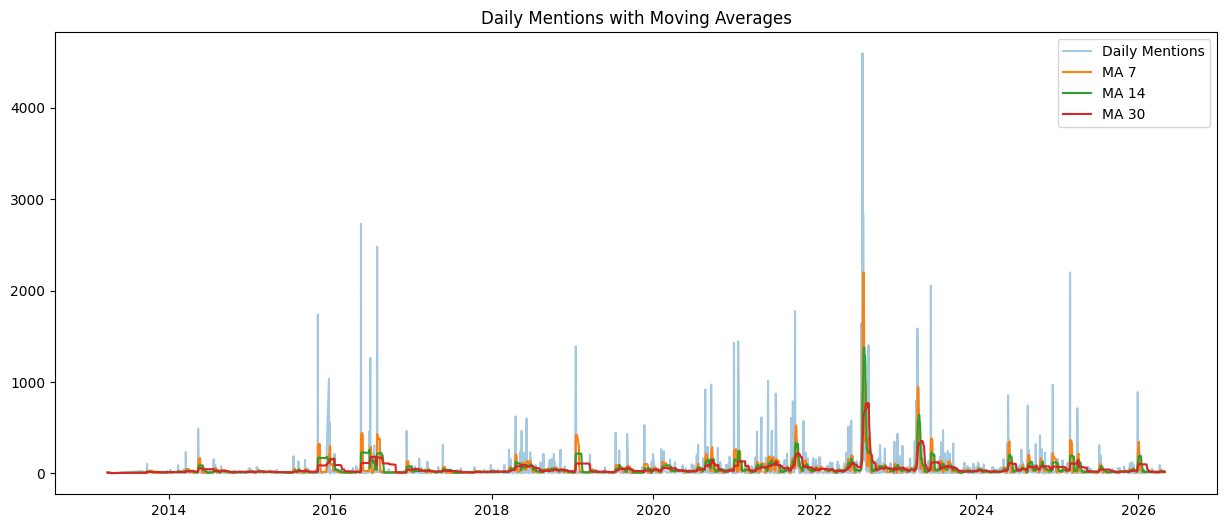

In [10]:
plt.figure(figsize=(15,6))

plt.plot(daily_counts['SQLDATE'], daily_counts['NumMentions'], 
         label='Daily Mentions', alpha=0.4)

plt.plot(daily_counts['SQLDATE'], daily_counts['ma_7'], label='MA 7')
plt.plot(daily_counts['SQLDATE'], daily_counts['ma_14'], label='MA 14')
plt.plot(daily_counts['SQLDATE'], daily_counts['ma_30'], label='MA 30')

plt.legend()
plt.title('Daily Mentions with Moving Averages')
plt.show()

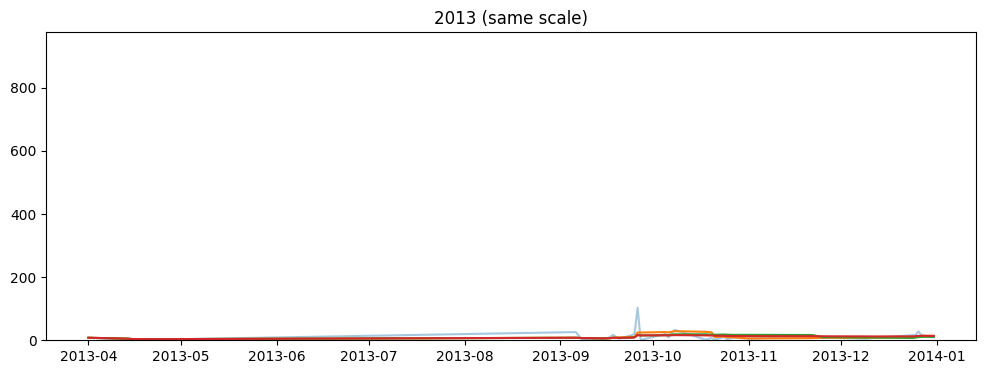

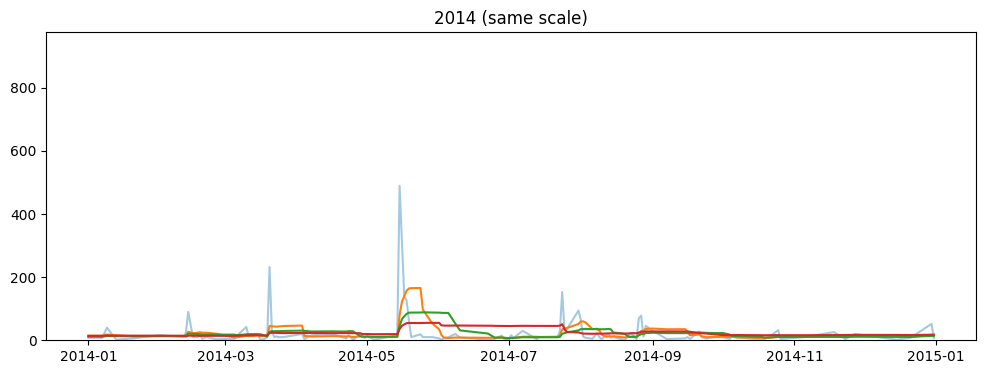

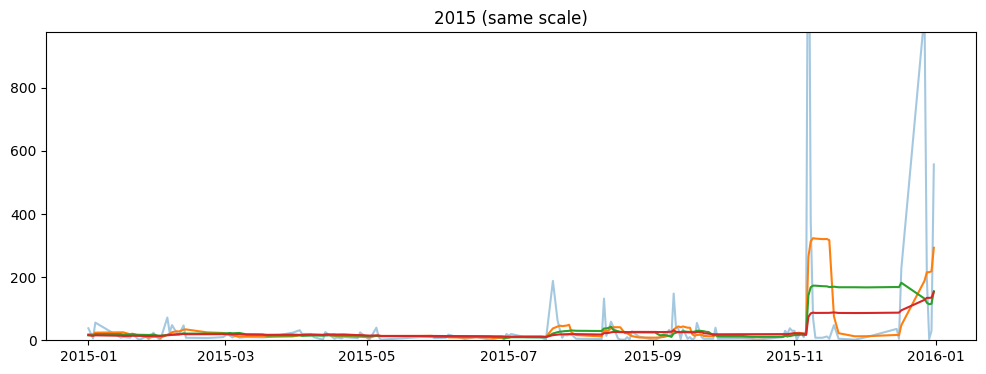

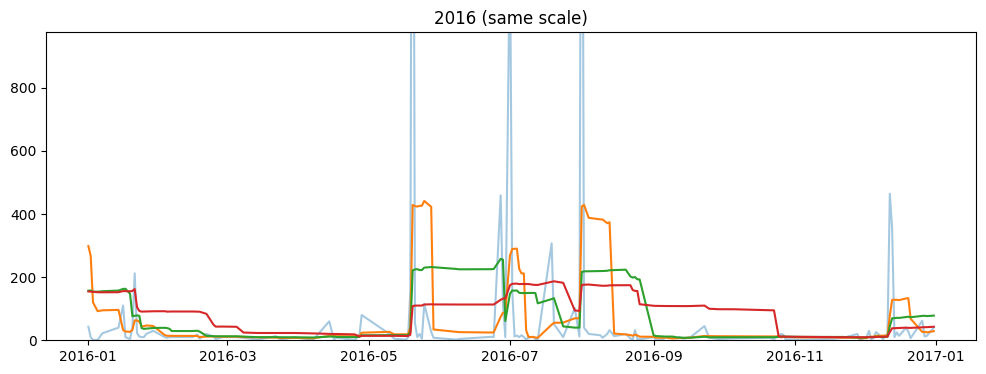

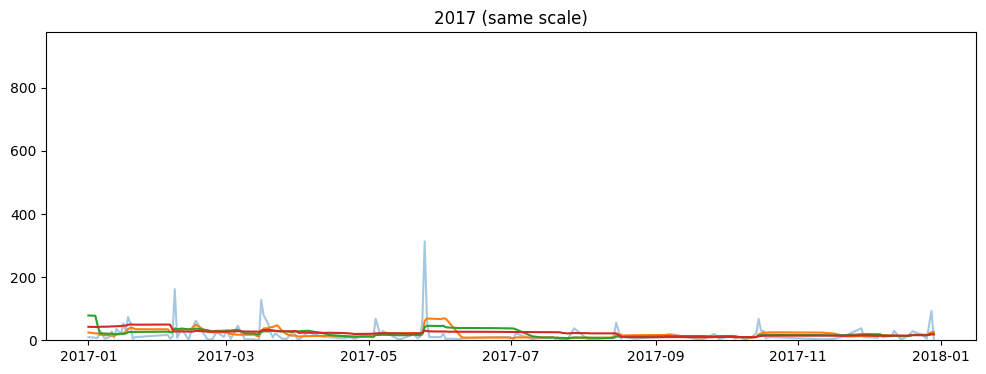

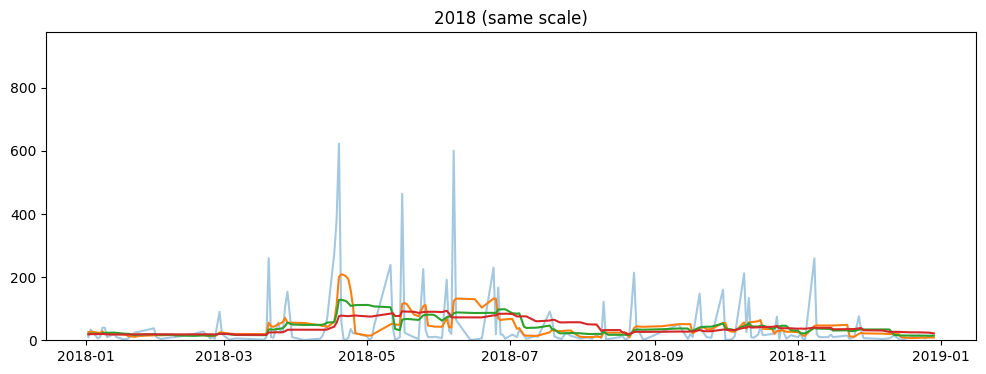

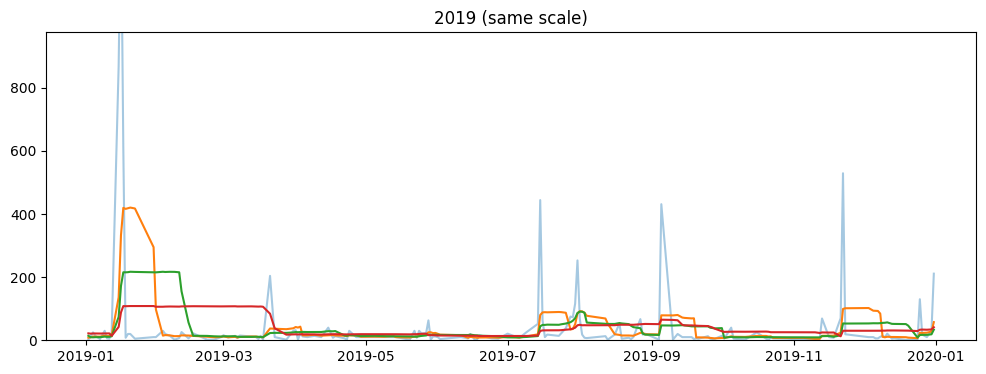

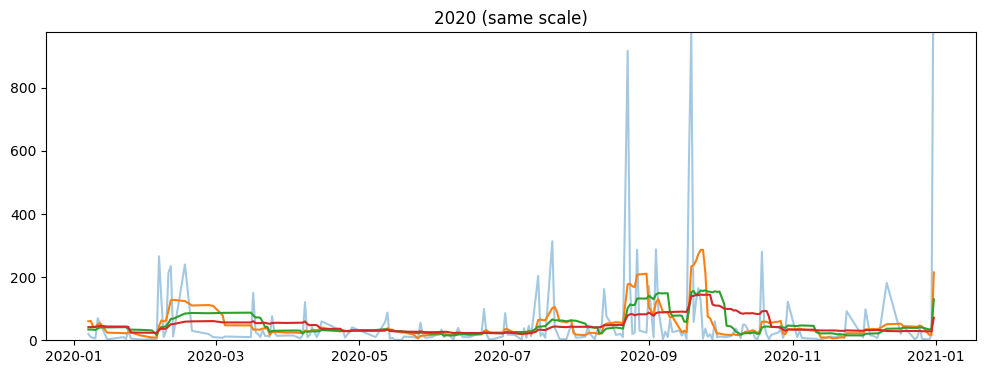

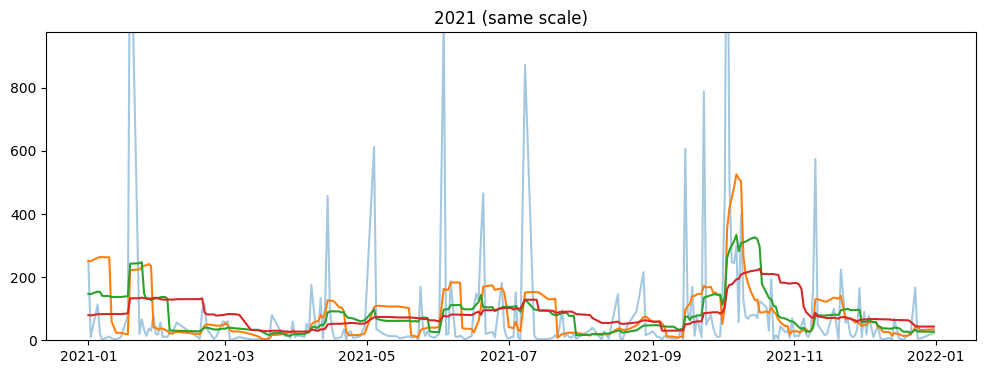

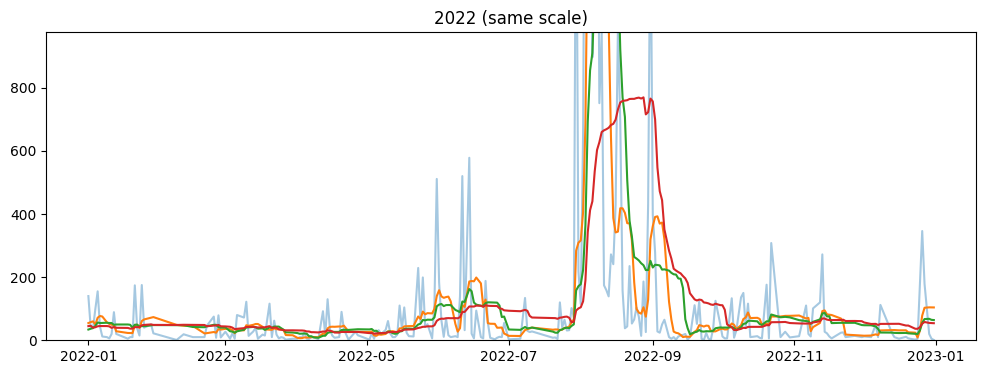

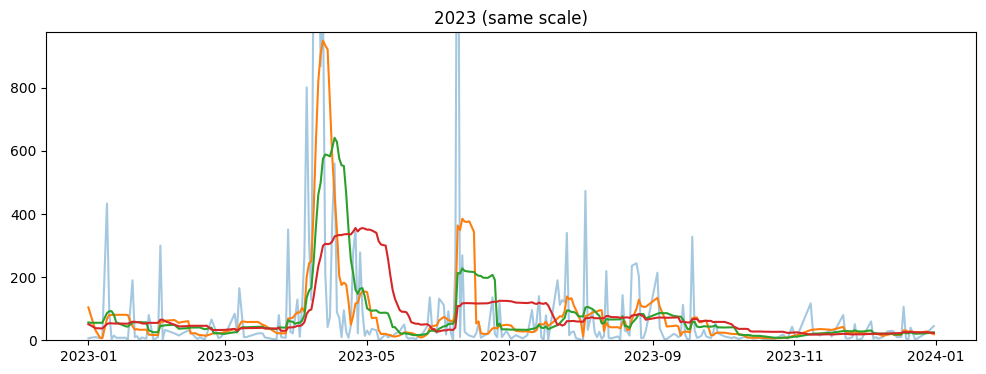

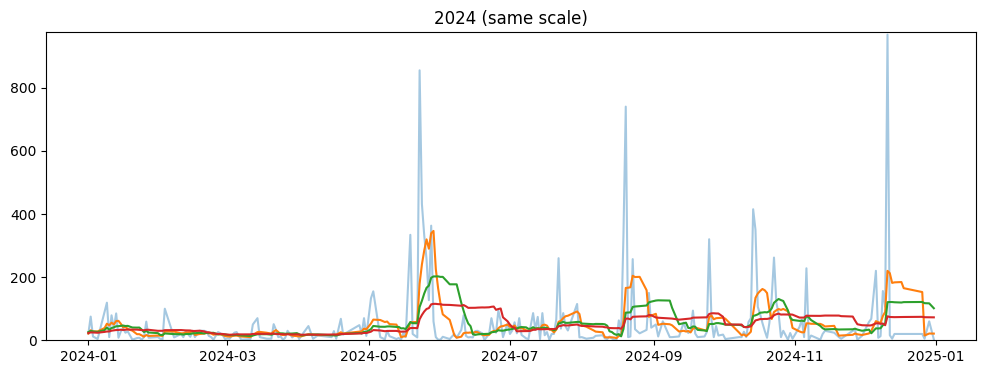

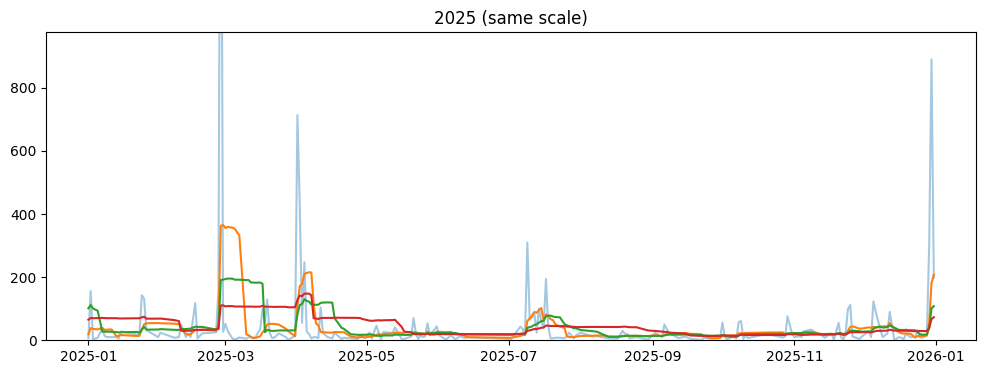

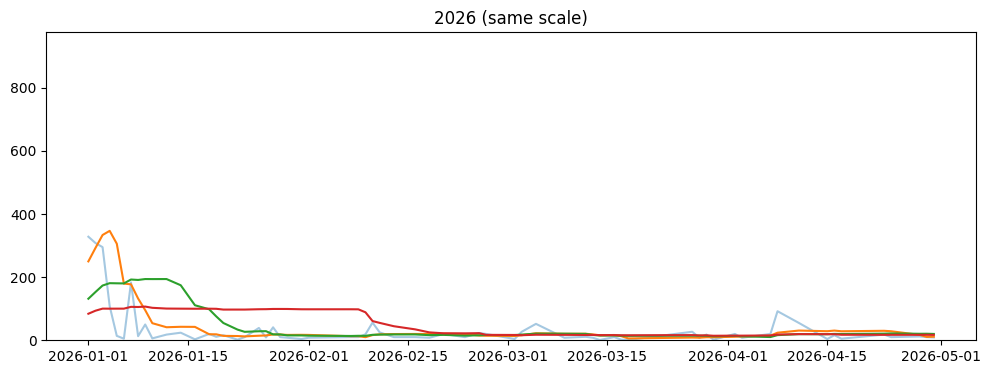

In [ ]:
## 연도별로 쪼개서.. + y축 고정까지
daily_counts['year'] = daily_counts['SQLDATE'].dt.year
years = sorted(daily_counts['year'].unique())

y_max = daily_counts['NumMentions'].quantile(0.99)  # extreme outlier 제거

for y in years:
    temp = daily_counts[daily_counts['year'] == y]
    
    plt.figure(figsize=(12,4))
    plt.plot(temp['SQLDATE'], temp['NumMentions'], alpha=0.4)
    plt.plot(temp['SQLDATE'], temp['ma_7'])
    plt.plot(temp['SQLDATE'], temp['ma_14'])
    plt.plot(temp['SQLDATE'], temp['ma_30'])
    
    plt.ylim(0, y_max)
    plt.title(f'{y} (same scale)')
    plt.show()

#### 결과 해석
- MA 7: 너무 민감 (nosie 많음)

- MA 14: spike 잡음, noise 상대적 제거됨. -> 이벤트 지속 기간과 맞음 (대략 1~2주 간격)

- MA 30: spike 이후에도 계속 높게 유지됨 -> 반응이 너무 느린듯 -> 이벤트 탐지 시점 늦어질 가능성 UP.

In [12]:
## 증가율 계산
for window in [7, 14, 30]:
    daily_counts[f'growth_{window}'] = (
        (daily_counts['NumMentions'] - daily_counts[f'ma_{window}']) 
        / daily_counts[f'ma_{window}']
    )

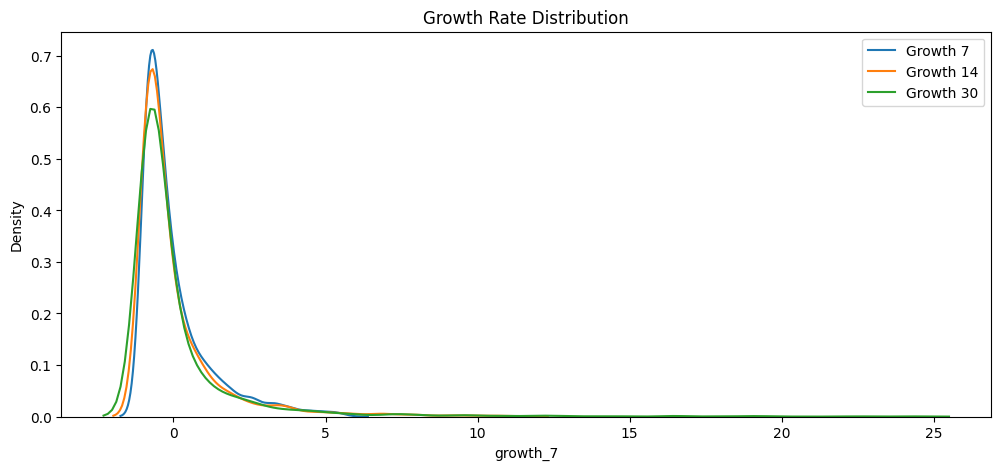

In [13]:
plt.figure(figsize=(12,5))

for window in [7, 14, 30]:
    sns.kdeplot(daily_counts[f'growth_{window}'], label=f'Growth {window}')

plt.legend()
plt.title('Growth Rate Distribution')
plt.show()

In [17]:
for window in [7,14,30]:
    print(f"{window}일 기준")
    print(daily_counts[f'growth_{window}'].describe())
    print()

7일 기준
count      2414.0
mean     0.025786
std      1.182421
min     -0.994341
25%     -0.758621
50%     -0.410549
75%       0.32126
max      5.646512
Name: growth_7, dtype: Float64

14일 기준
count       2414.0
mean      0.043644
std       1.553578
min      -0.993513
25%      -0.812528
50%      -0.521181
75%       0.222443
max      11.328493
Name: growth_14, dtype: Float64

30일 기준
count       2414.0
mean      0.060553
std       2.061936
min      -0.995229
25%      -0.845537
50%      -0.611135
75%       0.016618
max      24.198523
Name: growth_30, dtype: Float64



In [18]:
for window in [7,14,30]:
    print(f"{window}일 95%:", daily_counts[f'growth_{window}'].quantile(0.95))

7일 95%: 2.644552023121386
14일 95%: 3.2043362831858397
30일 95%: 3.176748178137652


#### 결과 해석
- growth = (오늘 - MA) / MA
- 오늘 기사량이 과거 평균 대비 약 (growth+1)배
- 7일
- 14일
- 30일
    - max = 24: baseline이 너무 낮을 때 폭발적으로 증가할 수 있음 -> 노이즈에 취약

In [19]:
## 기사량 절대값 기준 분석
daily_counts['NumMentions'].describe()

count        2414.0
mean      65.547639
std      217.945841
min             1.0
25%             8.0
50%            15.0
75%            38.0
max          4595.0
Name: NumMentions, dtype: Float64

- 중앙값 : 15
- 평균 : 65 -> 이상치 영향 큼
- 대부분 이벤트는 10~40 수준임

In [20]:
daily_counts['NumMentions'].quantile([0.9, 0.95, 0.99])

0.90     126.7
0.95    252.35
0.99    975.48
Name: NumMentions, dtype: Float64

- 상위 구간 비교: 100 이상부터는 이미 '비정상적으로 많은 기사'임을 의미함.

### 1-2. 날짜별? CAMEO Code 별? 같은 사건에 대한 기사량 분포

### 1-3. 

## 2. GoldsteinScale (이벤트 강도)
- 이 이벤트가 얼마나 위험한가...

## 3. AvgTone 분석 (뉴스 정서)
- 분위기 변화 감지
- 급격한 변화 탐지 -> 단순 기사량이 증가한 것인지, 실제 긴장이 고조된 건지 구분..